In [11]:
import pandas as pd
import numpy as np

In [12]:
csv_path = "../data/custom/orders.csv"
raw_csv_path = "../data/csv/Hackaton/Detalle_entrega.csv"
df = pd.read_csv(csv_path)

transport_col = "transport_id"
client_col = "client"
date_col = "date"
amount_col = "amount"
item_col = "item"
item_description_col = "item_description"
unit_col = "unit"

required_columns = {
    transport_col,
    client_col,
    date_col,
    amount_col,
    item_col,
    item_description_col,
    unit_col,
}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns in cleaned dataset: {sorted(missing_columns)}")

unique_clients_per_transport = df.groupby(transport_col)[client_col].nunique(dropna=True)
needs_client_recovery = (
    not unique_clients_per_transport.empty
    and unique_clients_per_transport.max() <= 1
)

if needs_client_recovery:
    raw_columns = [
        "FECHA",
        "Transporte",
        "Destinatario mc\u00eda.",
        "Nombre 1",
        "Material",
        "Cantidad entrega",
        "Un.medida venta",
    ]
    raw_df = pd.read_csv(raw_csv_path, usecols=raw_columns).rename(
        columns={
            "FECHA": date_col,
            "Transporte": transport_col,
            "Destinatario mc\u00eda.": "client_id",
            "Nombre 1": "client_name",
            "Material": item_col,
            "Cantidad entrega": amount_col,
            "Un.medida venta": unit_col,
        }
    )

    raw_df[unit_col] = raw_df[unit_col].astype(str).str.strip().str.lower()
    raw_df[amount_col] = pd.to_numeric(raw_df[amount_col], errors="coerce")
    raw_df = raw_df[raw_df[amount_col].notna()].copy()
    df[amount_col] = pd.to_numeric(df[amount_col], errors="coerce")

    merge_cols = [date_col, transport_col, item_col, amount_col, unit_col]
    for col in [date_col, transport_col, item_col, unit_col]:
        df[col] = df[col].astype(str).str.strip()
        raw_df[col] = raw_df[col].astype(str).str.strip()

    df["_match_seq"] = df.groupby(merge_cols).cumcount()
    raw_df["_match_seq"] = raw_df.groupby(merge_cols).cumcount()

    df = df.merge(
        raw_df[merge_cols + ["_match_seq", "client_id", "client_name"]],
        on=merge_cols + ["_match_seq"],
        how="left",
    )
    df = df.drop(columns=["_match_seq"])

    df["analysis_client"] = (
        df["client_name"].fillna(df["client_id"]).fillna(df[client_col]).astype(str).str.strip()
    )
    print("Recovered client identity from raw dataset for clustering analysis.")
else:
    df["analysis_client"] = df[client_col].astype(str).str.strip()

client_col = "analysis_client"

In [13]:
from collections import Counter
from itertools import combinations

pair_counts = Counter()

for transport_id, df_transport in df.groupby(transport_col):
    clients = sorted(df_transport[client_col].dropna().astype(str).unique())
    if len(clients) < 2:
        continue
    for pair in combinations(clients, 2):
        pair_counts[pair] += 1

pairs_df = (
    pd.DataFrame(
        [(c1, c2, cnt) for (c1, c2), cnt in pair_counts.items()],
        columns=["client_1", "client_2", "times_together"],
    )
    .sort_values("times_together", ascending=False)
    .reset_index(drop=True)
)

print(f"Unique client pairs found: {len(pairs_df)}")
print(f"Total co-occurrence events: {pairs_df['times_together'].sum()}")
pairs_df.head(10)

Unique client pairs found: 24145
Total co-occurrence events: 48872


,client_1,client_2,times_together
0,CAFE DE LA CORONA,PA TONET,17
1,BONATAPA,Bar 20 PA K,17
2,BAR DE LA BENZINERA,BAR DE LA BENZINERA HIGIENE,17
3,BRUNCH 4.12 MUSIC,CAFETERIA ANGELA,17
4,RESTAURANT NOU PAMPLONA,RESTAURANT NOU PAMPLONA HIGIENE,16
5,BAR LOS GALLEGOS,LA PERGOLA,16
6,CAFE SANT ROC,PA TONET,16
7,CAFE DE LA CORONA,PURE COFFEE,16
8,CAFE DE LA CORONA,CAFE SANT ROC,16
9,BAR RESTAURANT PAVEPIC,BAR XARANA GRANOLLERS,15


In [14]:
client_frequency = (
    df[[client_col, transport_col]]
    .dropna(subset=[client_col, transport_col])
    .assign(
        **{
            client_col: lambda x: x[client_col].astype(str).str.strip(),
            transport_col: lambda x: x[transport_col].astype(str).str.strip(),
        }
    )
    .drop_duplicates(subset=[client_col, transport_col])
    .groupby(client_col)[transport_col]
    .count()
    .rename("deliveries")
)

pairs_df["freq_1"] = pairs_df["client_1"].map(client_frequency).fillna(0)
pairs_df["freq_2"] = pairs_df["client_2"].map(client_frequency).fillna(0)
pairs_df["min_client_freq"] = pairs_df[["freq_1", "freq_2"]].min(axis=1)
pairs_df["normalized_score"] = np.where(
    pairs_df["min_client_freq"] > 0,
    pairs_df["times_together"] / pairs_df["min_client_freq"],
    0.0,
)
pairs_df = pairs_df.sort_values("normalized_score", ascending=False).reset_index(drop=True)

top_x_clients = 5000

top_clients = set(client_frequency.head(top_x_clients).index)

filtered_pairs_df = pairs_df[
    pairs_df["client_1"].isin(top_clients) & pairs_df["client_2"].isin(top_clients)
].copy()
filtered_pairs_df = filtered_pairs_df.sort_values("normalized_score", ascending=False).reset_index(drop=True)

print(f"Total unique clients: {client_frequency.shape[0]}")
print(f"Top-X selected clients: {len(top_clients)}")
print(f"Pairs kept after top-X filter: {len(filtered_pairs_df)}")

Total unique clients: 1184
Top-X selected clients: 500
Pairs kept after top-X filter: 4812


In [15]:
import networkx as nx
import community as community_louvain

G = nx.Graph()
G.add_nodes_from(top_clients)

min_normalized_score = 0.0
edges = filtered_pairs_df[filtered_pairs_df["normalized_score"] > min_normalized_score]

for _, row in edges.iterrows():
    G.add_edge(row["client_1"], row["client_2"], weight=row["normalized_score"])

isolated = list(nx.isolates(G))
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Isolated nodes (no edges): {len(isolated)}")
print(f"Connected components: {nx.number_connected_components(G)}")

Graph: 500 nodes, 4812 edges
Isolated nodes (no edges): 5
Connected components: 6


In [16]:
target_cluster_size = 30

# Louvain resolution controls granularity: higher = more smaller clusters.
# Start with an estimate and refine.
resolution = 1.0

partition = community_louvain.best_partition(
    G, weight="weight", resolution=resolution, random_state=42
)

modularity = community_louvain.modularity(partition, G, weight="weight")

raw_clusters = {}
for client, cid in partition.items():
    raw_clusters.setdefault(cid, set()).add(client)

sizes = [len(c) for c in raw_clusters.values()]
print(f"Resolution: {resolution}")
print(f"Modularity: {modularity:.4f}")
print(f"Raw clusters: {len(raw_clusters)}")
print(f"Cluster sizes: min={min(sizes)}, median={int(np.median(sizes))}, max={max(sizes)}, mean={np.mean(sizes):.1f}")
print(f"Singletons: {sum(1 for s in sizes if s == 1)}")
print(f"Clusters > {target_cluster_size}: {sum(1 for s in sizes if s > target_cluster_size)}")

Resolution: 1.0
Modularity: 0.7939
Raw clusters: 16
Cluster sizes: min=1, median=22, max=85, mean=31.2
Singletons: 5
Clusters > 30: 7


In [17]:
# Auto-tune resolution to get median cluster size close to target_cluster_size.
best_res = resolution
best_diff = abs(np.median(sizes) - target_cluster_size)
best_partition = partition

for res in np.arange(0.1, 5.1, 0.1):
    p = community_louvain.best_partition(G, weight="weight", resolution=res, random_state=42)
    clusters_tmp = {}
    for client, cid in p.items():
        clusters_tmp.setdefault(cid, set()).add(client)
    med = np.median([len(c) for c in clusters_tmp.values()])
    diff = abs(med - target_cluster_size)
    if diff < best_diff:
        best_diff = diff
        best_res = res
        best_partition = p

partition = best_partition
modularity = community_louvain.modularity(partition, G, weight="weight")

raw_clusters = {}
for client, cid in partition.items():
    raw_clusters.setdefault(cid, set()).add(client)

sizes = [len(c) for c in raw_clusters.values()]
print(f"Best resolution: {best_res:.1f}")
print(f"Modularity: {modularity:.4f}")
print(f"Raw clusters: {len(raw_clusters)}")
print(f"Cluster sizes: min={min(sizes)}, median={int(np.median(sizes))}, max={max(sizes)}, mean={np.mean(sizes):.1f}")
print(f"Singletons: {sum(1 for s in sizes if s == 1)}")
print(f"Clusters > {target_cluster_size}: {sum(1 for s in sizes if s > target_cluster_size)}")

Best resolution: 0.4
Modularity: 0.7911
Raw clusters: 15
Cluster sizes: min=1, median=29, max=92, mean=33.3
Singletons: 5
Clusters > 30: 7


In [18]:
# Post-process: split oversized clusters and merge tiny ones.
max_cluster_size = 40
min_cluster_size = 5


def split_cluster(members, graph, max_size):
    """Recursively bisect a cluster using graph structure until all parts <= max_size."""
    if len(members) <= max_size:
        return [members]

    subgraph = graph.subgraph(members).copy()
    if subgraph.number_of_edges() == 0:
        members_list = sorted(members)
        parts = []
        for i in range(0, len(members_list), max_size):
            parts.append(set(members_list[i : i + max_size]))
        return parts

    sub_partition = community_louvain.best_partition(
        subgraph, weight="weight", resolution=2.0, random_state=42
    )
    sub_clusters = {}
    for node, cid in sub_partition.items():
        sub_clusters.setdefault(cid, set()).add(node)

    if len(sub_clusters) <= 1:
        members_list = sorted(members)
        parts = []
        for i in range(0, len(members_list), max_size):
            parts.append(set(members_list[i : i + max_size]))
        return parts

    result = []
    for part in sub_clusters.values():
        result.extend(split_cluster(part, graph, max_size))
    return result


balanced_clusters = []
for members in raw_clusters.values():
    if len(members) > max_cluster_size:
        balanced_clusters.extend(split_cluster(members, G, max_cluster_size))
    else:
        balanced_clusters.append(members)

# Merge tiny clusters into the nearest neighbor cluster by total edge weight.
final_clusters = []
tiny_clients = []
for cluster in balanced_clusters:
    if len(cluster) < min_cluster_size:
        tiny_clients.extend(cluster)
    else:
        final_clusters.append(set(cluster))

for client in tiny_clients:
    best_idx = None
    best_weight = -1
    for idx, cluster in enumerate(final_clusters):
        if len(cluster) >= max_cluster_size:
            continue
        w = sum(G[client][neighbor].get("weight", 0) for neighbor in cluster if G.has_edge(client, neighbor))
        if w > best_weight:
            best_weight = w
            best_idx = idx
    if best_idx is not None:
        final_clusters[best_idx].add(client)
    else:
        final_clusters.append({client})

final_clusters = [c for c in final_clusters if c]

sizes = [len(c) for c in final_clusters]
print(f"Balanced clusters: {len(final_clusters)}")
print(f"Cluster sizes: min={min(sizes)}, median={int(np.median(sizes))}, max={max(sizes)}, mean={np.mean(sizes):.1f}")
print(f"Singletons: {sum(1 for s in sizes if s == 1)}")

Balanced clusters: 49
Cluster sizes: min=5, median=10, max=29, mean=10.2
Singletons: 0


Total clusters: 49
Largest cluster: 29
Smallest cluster: 5
Singletons: 0
Modularity: 0.7911


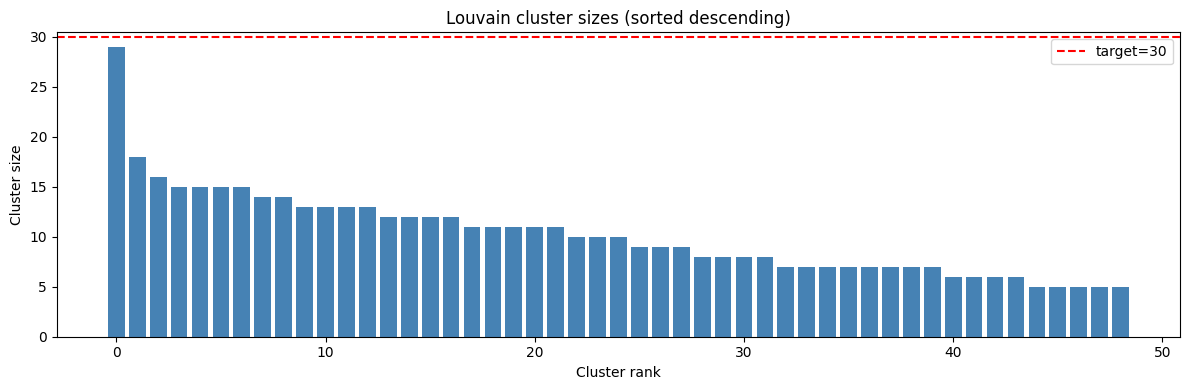

,cluster_id,cluster_size,members
0,26,29,"[BAR CAMP FUTBOL ST PERE TORELLO, BAR CAMP FUT..."
1,29,18,"[ASSEMBLEA JOVE VIC, B&B, B-VIKY, BAR ATLANTID..."
2,31,16,"[2 PRINCIPE, ALOE, AURIAL PADEL, BAR CAFETERIA..."
3,14,15,"[AQUI MATEIX, BAR ""LA OCA"", BAR AMISTAD, BAR C..."
4,20,15,"[ALBA AUDIOVISUALS, BAR CA LA MARI, BAR CAFETE..."
5,25,15,"[A VOCADOS, ATARASII, BAR CAPARROS, BAR LA LOL..."
6,27,15,"[AIRE, AUTENTIK'S, AUTENTIK’S CAMPO DE FUTBOL,..."
7,0,14,"[' EL NOU' TOÓ RICO, 412 COFFEE BEER, ALFREDO ..."
8,4,14,"[(RESTAURANT) SPORT & HEALTH OXIGEN, BAR BOTE,..."
9,2,13,"[AAVV SANTA ROSA, AMBIGU, BAR 28, BAR CAFETERI..."


In [19]:
import matplotlib.pyplot as plt

cluster_rows = [
    {
        "cluster_id": idx,
        "cluster_size": len(cluster),
        "members": sorted(cluster),
    }
    for idx, cluster in enumerate(final_clusters)
]

clusters_df = (
    pd.DataFrame(cluster_rows)
    .sort_values(["cluster_size", "cluster_id"], ascending=[False, True])
    .reset_index(drop=True)
)

print(f"Total clusters: {len(clusters_df)}")
print(f"Largest cluster: {clusters_df['cluster_size'].max()}")
print(f"Smallest cluster: {clusters_df['cluster_size'].min()}")
print(f"Singletons: {(clusters_df['cluster_size'] == 1).sum()}")
print(f"Modularity: {modularity:.4f}")

plt.figure(figsize=(12, 4))
plt.bar(range(len(clusters_df)), clusters_df["cluster_size"].values, color="steelblue")
plt.axhline(y=target_cluster_size, color="red", linestyle="--", label=f"target={target_cluster_size}")
plt.xlabel("Cluster rank")
plt.ylabel("Cluster size")
plt.title("Louvain cluster sizes (sorted descending)")
plt.legend()
plt.tight_layout()
plt.show()

clusters_df.head(60)

In [20]:
import json
from pathlib import Path

cluster_source = "louvain"

data_custom_dir = next(
    (path for path in [Path("../data/custom"), Path("data/custom")] if path.exists()),
    Path("../data/custom"),
)
output_dir = data_custom_dir / "clustering" / cluster_source
output_dir.mkdir(parents=True, exist_ok=True)

clusters_export_df = clusters_df.copy()
clusters_export_df["members_json"] = clusters_export_df["members"].map(
    lambda members: json.dumps(list(members), ensure_ascii=False)
)
clusters_export_df = clusters_export_df[["cluster_id", "cluster_size", "members_json"]]

cluster_lookup_df = (
    clusters_df[["cluster_id", "cluster_size", "members"]]
    .explode("members")
    .rename(columns={"members": "client_name"})
    .dropna(subset=["client_name"])
    .reset_index(drop=True)
)
cluster_lookup_df["client_name"] = cluster_lookup_df["client_name"].astype(str).str.strip()
cluster_lookup_df = cluster_lookup_df[cluster_lookup_df["client_name"] != ""].copy()
cluster_lookup_df["cluster_source"] = cluster_source

clusters_path = output_dir / "clusters.csv"
lookup_path = output_dir / "client_cluster_lookup.csv"
clusters_export_df.to_csv(clusters_path, index=False)
cluster_lookup_df.to_csv(lookup_path, index=False)

print(f"Exported clusters: {len(clusters_export_df):,} rows -> {clusters_path.resolve()}")
print(f"Exported client lookup: {len(cluster_lookup_df):,} rows -> {lookup_path.resolve()}")

cluster_lookup_df.head()

Exported clusters: 49 rows -> /Users/luka.papez/Code/personal/damm-hackathon/data/custom/clustering/louvain/clusters.csv
Exported client lookup: 500 rows -> /Users/luka.papez/Code/personal/damm-hackathon/data/custom/clustering/louvain/client_cluster_lookup.csv


,cluster_id,cluster_size,client_name,cluster_source
0,26,29,BAR CAMP FUTBOL ST PERE TORELLO,louvain
1,26,29,BAR CAMP FUTBOL ST VICENÇ TORELLO,louvain
2,26,29,BAR CANIGO,louvain
3,26,29,BAR CASAL ST. VICEN#,louvain
4,26,29,BAR COOPERATIVA,louvain
